In [4]:
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [3]:
%%R
install.packages("outliers")
library(outliers)
install.packages("VIM", repos="https://cloud.r-project.org")
library(VIM)
install.packages("car")
install.packages("mice")
library(mice)
library(car)
install.packages("nortest")
install.packages("goftest")
library(nortest)
library(goftest)


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/outliers_0.15.tar.gz'
Content type 'application/x-gzip' length 15967 bytes (15 KB)
downloaded 15 KB


The downloaded source packages are in
	‘/tmp/RtmpKMmbJo/downloaded_packages’
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cloud.r-project.org/src/contrib/VIM_6.2.6.tar.gz'
Content type 'application/x-gzip' length 2039466 bytes (1.9 MB)
downloaded 1.9 MB


The downloaded source packages are in
	‘/tmp/RtmpKMmbJo/downloaded_packages’
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/car_3.1-3.tar.gz'
Content type 'application/x-gzip' length 384407 bytes (375 KB)
downloaded 375 KB


The downloaded source packages are in
	‘/tmp/RtmpKMmbJo/downloaded_packages’
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is

In [5]:
%%R
data <- read.csv(file = "Wdata.csv", header = TRUE)
head(data)

      Date.Time Temp_C Dew.Point.Temp_C Rel.Hum_. Wind.Speed_km.h Visibility_km
1 1/1/2012 0:00   -1.8             -3.9        86               4           8.0
2 1/1/2012 1:00   -1.8             -3.7        87               4           8.0
3 1/1/2012 2:00   -1.8             -3.4        89               7           4.0
4 1/1/2012 3:00   -1.5             -3.2        88               6           4.0
5 1/1/2012 4:00   -1.5             -3.3        88               7           4.8
6 1/1/2012 5:00   -1.4             -3.3        87               9           6.4
  Press_kPa              Weather
1    101.24                  Fog
2    101.24                  Fog
3    101.26 Freezing Drizzle,Fog
4    101.27 Freezing Drizzle,Fog
5    101.23                  Fog
6    101.27                  Fog


In [6]:
%%R
library(dplyr)

Data <- data.frame(
  name = character(),
  type = character(),
  max = numeric(),
  min = numeric(),
  mean = numeric(),
  number_of_passes = integer(),
  stringsAsFactors = FALSE
)

for (column_name in colnames(data)) {
  column_data <- data[[column_name]]

  sdsd <- suppressWarnings(tryCatch(
    mean(column_data, na.rm = TRUE),
    error = function(e) NA_real_
  ))

  col_type <- class(column_data)[1]

  col_max <- tryCatch(max(column_data, na.rm = TRUE), error = function(e) NA_real_)
  col_min <- tryCatch(min(column_data, na.rm = TRUE), error = function(e) NA_real_)

  num_na <- sum(is.na(column_data))

  Data <- rbind(Data, data.frame(
    name = column_name,
    type = col_type,
    max = col_max,
    min = col_min,
    mean = sdsd,
    number_of_passes = num_na,
    stringsAsFactors = FALSE
  ))
}

print(Data)

              name      type                    max           min       mean
1        Date.Time character          9/9/2012 9:00 1/1/2012 0:00         NA
2           Temp_C   numeric                     33         -23.3   8.798144
3 Dew.Point.Temp_C   numeric                   24.4         -28.5   2.555294
4        Rel.Hum_.   integer                    100            18  67.431694
5  Wind.Speed_km.h   integer                     83             0  14.945469
6    Visibility_km   numeric                   48.3           0.2  27.664447
7        Press_kPa   numeric                 103.65         97.52 101.051623
8          Weather character Thunderstorms,Rain,Fog         Clear         NA
  number_of_passes
1                0
2                0
3                0
4                0
5                0
6                0
7                0
8                0



Attaching package: ‘dplyr’

The following object is masked from ‘package:car’:

    recode

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



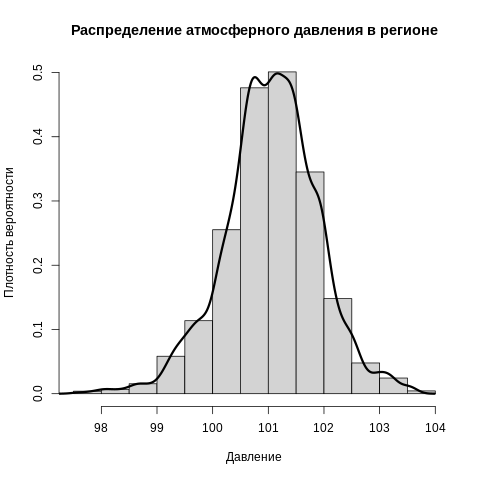

In [7]:
%%R
Data <- data$Press_kPa
hist(Data, breaks = 20, freq = FALSE,
     xlab = "Давление",
     ylab = "Плотность вероятности",
     main = "Распределение атмосферного давления в регионе")
lines(density(Data), lwd = 3)

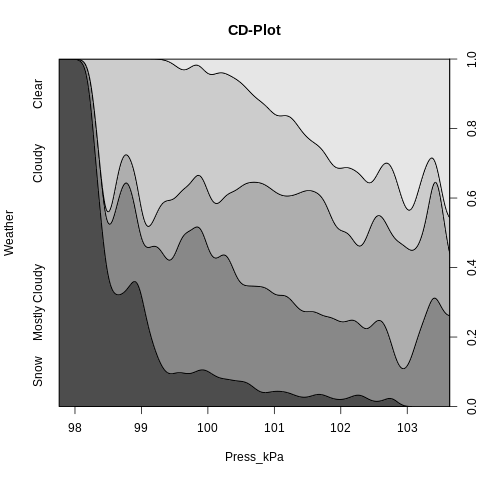

In [8]:
%%R
library(dplyr)

top5_weather <- data %>%
  count(Weather) %>%
  arrange(desc(n)) %>%
  slice_head(n = 5) %>%
  pull(Weather)

filtered_data <- data[data$Weather %in% top5_weather, ]
filtered_data$Weather <- as.factor(filtered_data$Weather)

cdplot(Weather ~ Press_kPa, data = filtered_data, main="CD-Plot")

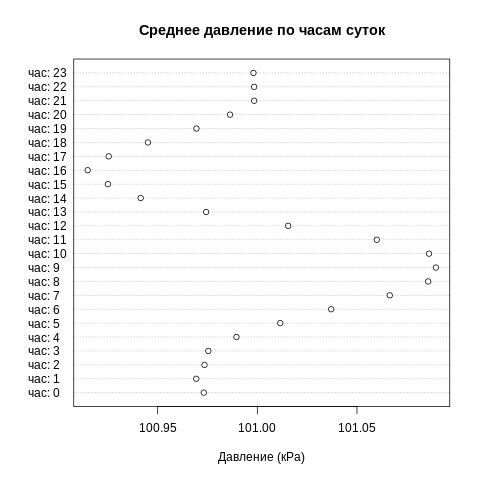

In [9]:
%%R
data$hour <- as.numeric(format(as.POSIXct(data$Date.Time, format="%d/%m/%Y %H:%M"), "%H"))

hourly_means <- aggregate(Press_kPa ~ hour, data = data, FUN = mean)

hourly_means <- hourly_means[order(hourly_means$hour), ]

dotchart(hourly_means$Press_kPa,
         labels = paste("час:", hourly_means$hour),
         main = "Среднее давление по часам суток",
         xlab = "Давление (кPa)")

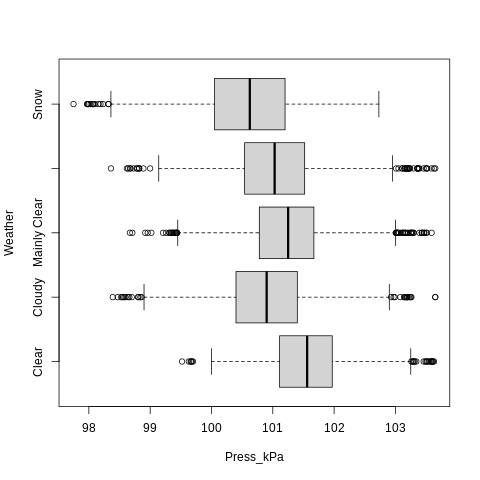

In [10]:
%%R
library(dplyr)
boxplot(Press_kPa ~ Weather , data = filtered_data,horizontal=TRUE)

In [11]:
%%R
#Strip_Plot
#stripchart(Press_kPa[1:1000] ~ Date.Time[1:1000], data = data, method = "jitter", jitter = 0.45, pch = 1, vertical = TRUE)

NULL


In [12]:
%%R
install.packages("ggplot2")
library(ggplot2)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/ggplot2_4.0.1.tar.gz'
Content type 'application/x-gzip' length 6343443 bytes (6.0 MB)
downloaded 6.0 MB


The downloaded source packages are in
	‘/tmp/RtmpKMmbJo/downloaded_packages’


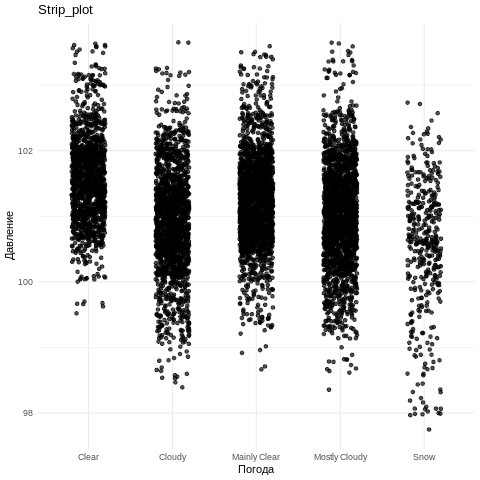

In [13]:
%%R

ggplot(filtered_data, aes(x = Weather, y = Press_kPa)) +geom_jitter(width = 0.2, alpha = 0.7) + labs(title = "Strip_plot",x = "Погода",y = "Давление") +theme_minimal()


	Grubbs test for one outlier

data:  data$Press_kPa
G = 4.18436, U = 0.99801, p-value = 0.1245
alternative hypothesis: lowest value 97.52 is an outlier


	Grubbs test for one outlier

data:  data$Press_kPa
G = 3.07863, U = 0.99892, p-value = 1
alternative hypothesis: highest value 103.65 is an outlier


	Dixon test for outliers

data:  data$Press_kPa[101:130]
Q = 0.10938, p-value = 0.4797
alternative hypothesis: lowest value 100.19 is an outlier


	Dixon test for outliers

data:  data$Press_kPa[101:130]
Q = 0.033898, p-value = 0.07269
alternative hypothesis: highest value 100.85 is an outlier



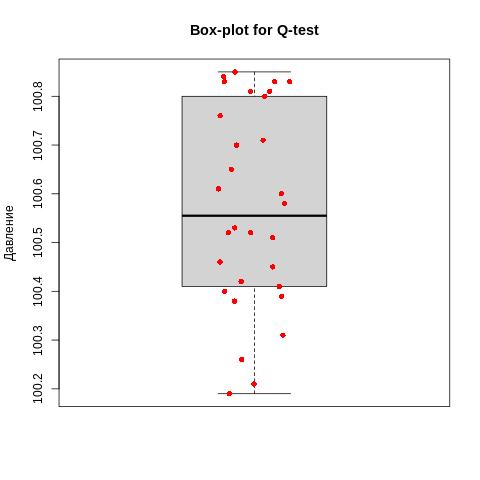

In [14]:
%%R
print(grubbs.test(data$Press_kPa))
print(grubbs.test(data$Press_kPa, opposite = TRUE))
print(dixon.test(data$Press_kPa[101:130]))
print(dixon.test(data$Press_kPa[101:130],opposite=TRUE))
boxplot(data$Press_kPa[101:130], main = "Box-plot for Q-test", ylab = "Давление")
stripchart(data$Press_kPa[101:130], vertical = TRUE, method = "jitter", pch = 16, col = "red", add = TRUE)


Заполнение пропусков:

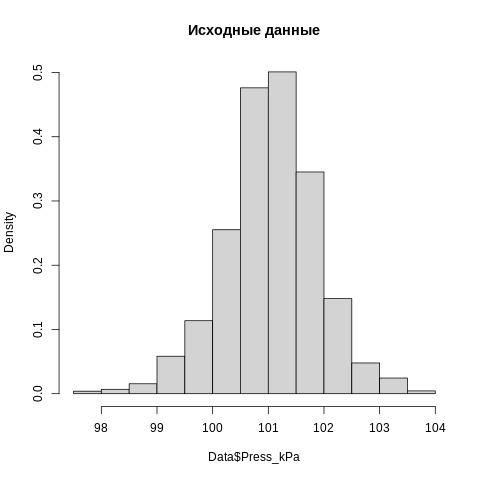

In [15]:
%%R
library(VIM)

Data <- data

hist(Data$Press_kPa, breaks = 20, freq = FALSE, main = "Исходные данные")


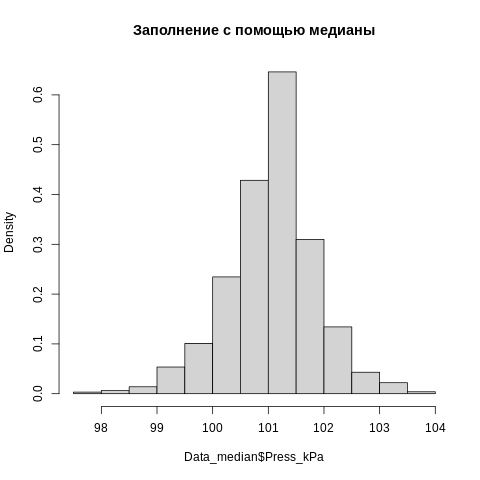

In [16]:
%%R
library(VIM)


Data <- data

n <- nrow(Data)
missing_indices <- sample(1:n, size = round(0.1 * n))
Data_with_missing <- Data
Data_with_missing$Press_kPa[missing_indices] <- NA


Data_median <- Data_with_missing
Data_median$Press_kPa[is.na(Data_median$Press_kPa)] <- median(Data_median$Press_kPa, na.rm = TRUE)
hist(Data_median$Press_kPa, breaks = 20, freq = FALSE, main = "Заполнение с помощью медианы")

          Temp_C Dew.Point.Temp_C        Rel.Hum_.  Wind.Speed_km.h 
           -23.3            -28.5             18.0              0.0 
   Visibility_km             hour           Temp_C Dew.Point.Temp_C 
             0.2              0.0             33.0             24.4 
       Rel.Hum_.  Wind.Speed_km.h    Visibility_km             hour 
           100.0             83.0             48.3             23.0 

--- Results ---
Median method MSE: 0.8313092 
KNN method MSE: 0.7856855 


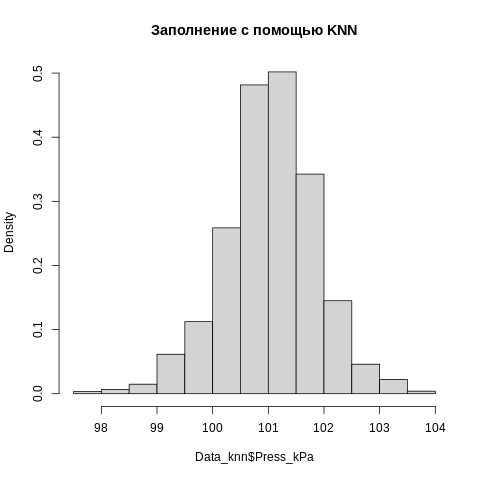

In [17]:
%%R
library(VIM)

Data <- data



Data_knn <- kNN(Data_with_missing, variable = "Press_kPa", k = 5)
hist(Data_knn$Press_kPa, breaks = 20, freq = FALSE, main = "Заполнение с помощью KNN")

original_values <- Data$Press_kPa[missing_indices]
mse_median <- sqrt(sum((Data_median$Press_kPa[missing_indices] - original_values)^2) / length(missing_indices))
mse_knn <- sqrt(sum((Data_knn$Press_kPa[missing_indices] - original_values)^2) / length(missing_indices))

cat("\n--- Results ---\n")
cat("Median method MSE:", mse_median, "\n")
cat("KNN method MSE:", mse_knn, "\n")

In [18]:
%%R
data1 <- rnorm(50, 0, 1)
data2 <- rnorm(50, 5, 10)

data3 <- rnorm(5000, 0, 1)
data4 <- rnorm(5000, 5, 10)

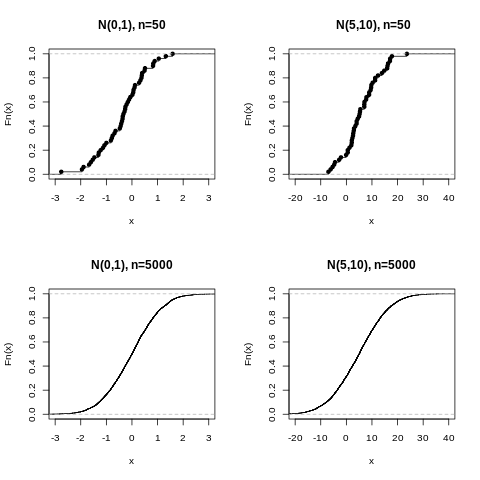

In [19]:
%%R
par(mfrow = c(2, 2))

e1 <- ecdf(data1)
plot(e1, main = "N(0,1), n=50", xlim = c(-3, 3), ylim = c(0,1))

e2 <- ecdf(data2)
plot(e2, main = " N(5,10), n=50", xlim = c(-20, 40), ylim = c(0,1))

e3 <- ecdf(data3)
plot(e3, main = "N(0,1), n=5000", xlim = c(-3, 3), ylim = c(0,1))

e4 <- ecdf(data4)
plot(e4, main = "N(5,10), n=5000", xlim = c(-20, 40), ylim = c(0,1))

par(mfrow = c(1, 1))


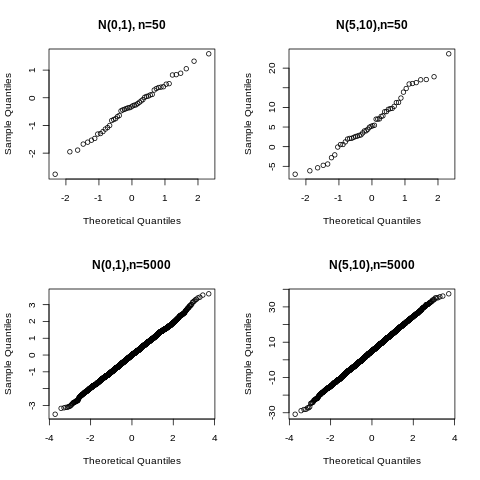

In [20]:
%%R
qqgraph <- function(x,s){
  qqnorm(x,main=s)
  #qqline(x)
}
par(mfrow = c(2, 2))

qqgraph(data1,"N(0,1), n=50")
qqgraph(data2,"N(5,10),n=50")
qqgraph(data3,"N(0,1),n=5000")
qqgraph(data4,"N(5,10),n=5000")

[1] 4027 1932


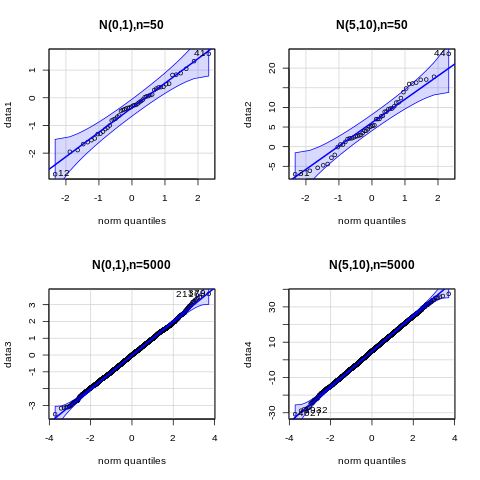

In [21]:
%%R
par(mfrow = c(2, 2))
#Метод огибающих
qqPlot(data1,main="N(0,1),n=50")
qqPlot(data2,main="N(5,10),n=50")
qqPlot(data3,main="N(0,1),n=5000")
qqPlot(data4,main="N(5,10),n=5000")

# Проверка гипотез о нормальности

In [22]:
%%R
library(nortest)
print(ks.test(data1,mean = mean(data1),sd=sd(data1), "pnorm"))
print(ks.test(data2,mean = mean(data2),sd=sd(data2), "pnorm"))
print(ks.test(data3,mean = mean(data3),sd=sd(data3), "pnorm"))
print(ks.test(data4,mean = mean(data4),sd=sd(data4), "pnorm"))


	Exact one-sample Kolmogorov-Smirnov test

data:  data1
D = 0.09057, p-value = 0.7729
alternative hypothesis: two-sided


	Exact one-sample Kolmogorov-Smirnov test

data:  data2
D = 0.079696, p-value = 0.8835
alternative hypothesis: two-sided


	Asymptotic one-sample Kolmogorov-Smirnov test

data:  data3
D = 0.0063833, p-value = 0.987
alternative hypothesis: two-sided


	Asymptotic one-sample Kolmogorov-Smirnov test

data:  data4
D = 0.0068659, p-value = 0.9725
alternative hypothesis: two-sided



In [23]:
%%R
print(shapiro.test(data1))
print(shapiro.test(data2))
print(shapiro.test(data3))
print(shapiro.test(data4))


	Shapiro-Wilk normality test

data:  data1
W = 0.99094, p-value = 0.9656


	Shapiro-Wilk normality test

data:  data2
W = 0.98099, p-value = 0.5944


	Shapiro-Wilk normality test

data:  data3
W = 0.99958, p-value = 0.3661


	Shapiro-Wilk normality test

data:  data4
W = 0.99976, p-value = 0.8735



In [32]:
%%R
print(nortest::ad.test(data1))
print(nortest::ad.test(data2))
print(nortest::ad.test(data3))
print(nortest::ad.test(data4))


	Anderson-Darling normality test

data:  data1
A = 7.9073, p-value < 2.2e-16


	Anderson-Darling normality test

data:  data2
A = 0.30391, p-value = 0.5589


	Anderson-Darling normality test

data:  data3
A = 0.31568, p-value = 0.5421


	Anderson-Darling normality test

data:  data4
A = 0.19139, p-value = 0.8971



In [31]:
%%R
print(nortest::cvm.test(data1))
print(nortest::cvm.test(data2))
print(nortest::cvm.test(data3))
print(nortest::cvm.test(data4))


	Cramer-von Mises normality test

data:  data1
W = 1.174, p-value = 7.37e-10


	Cramer-von Mises normality test

data:  data2
W = 0.045876, p-value = 0.567


	Cramer-von Mises normality test

data:  data3
W = 0.036952, p-value = 0.7374


	Cramer-von Mises normality test

data:  data4
W = 0.03358, p-value = 0.7945



In addition: Warning message:
In nortest::cvm.test(data1) :
  p-value is smaller than 7.37e-10, cannot be computed more accurately


In [29]:
%%R
library(nortest)
print(lillie.test(data1))
print(lillie.test(data2))
print(lillie.test(data3))
print(lillie.test(data4))


	Lilliefors (Kolmogorov-Smirnov) normality test

data:  data1
D = 0.030141, p-value = 3.56e-11


	Lilliefors (Kolmogorov-Smirnov) normality test

data:  data2
D = 0.079696, p-value = 0.5937


	Lilliefors (Kolmogorov-Smirnov) normality test

data:  data3
D = 0.0063833, p-value = 0.8912


	Lilliefors (Kolmogorov-Smirnov) normality test

data:  data4
D = 0.0068659, p-value = 0.8221



In [27]:
%%R
print(sf.test(data1))
print(sf.test(data2))
print(sf.test(data3))
print(sf.test(data4))



	Shapiro-Francia normality test

data:  data1
W = 0.98988, p-value = 0.8867


	Shapiro-Francia normality test

data:  data2
W = 0.98396, p-value = 0.633


	Shapiro-Francia normality test

data:  data3
W = 0.99961, p-value = 0.3637


	Shapiro-Francia normality test

data:  data4
W = 0.99982, p-value = 0.9548



# Проверка гипотез о нормальности на реальных данных:


	Asymptotic one-sample Kolmogorov-Smirnov test

data:  data1
D = 1, p-value < 2.2e-16
alternative hypothesis: two-sided


	Shapiro-Wilk normality test

data:  data1
W = 0.9913, p-value < 2.2e-16


	Anderson-Darling normality test

data:  data1
A = 7.9073, p-value < 2.2e-16


	Cramer-von Mises normality test

data:  data1
W = 1.174, p-value = 7.37e-10


	Lilliefors (Kolmogorov-Smirnov) normality test

data:  data1
D = 0.030141, p-value = 3.56e-11


	Shapiro-Francia normality test

data:  data1
W = 0.99142, p-value < 2.2e-16



In addition: Warning messages:
1: In ks.test.default(data1, "pnorm") :
  ties should not be present for the one-sample Kolmogorov-Smirnov test
2: In nortest::cvm.test(data1) :
  p-value is smaller than 7.37e-10, cannot be computed more accurately


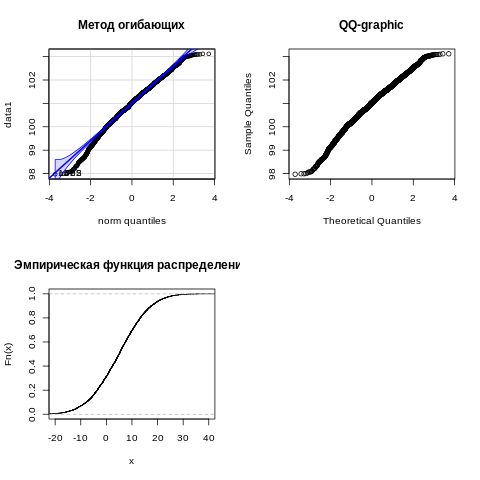

In [33]:
%%R
data1=data$Press_kPa[1:5000]
print(ks.test(data1, "pnorm"))
print(shapiro.test(data1))
print(nortest::ad.test(data1))
print(nortest::cvm.test(data1))
print(lillie.test(data1))
print(sf.test(data1))

par(mfrow = c(2, 2))
qqPlot(data1,main="Метод огибающих")
qqgraph(data1,"QQ-graphic")
e4 <- ecdf(data4)
plot(e4, main = "Эмпирическая функция распределения", xlim = c(-20, 40), ylim = c(0,1))